### Analysis of an E-commerce Dataset

We have been provided with a combined e-commerce dataset. In this dataset, each user has the ability to post a rating and review for the products they purchased. Additionally, other users can evaluate the initial rating and review by expressing their trust or distrust.

This dataset includes a wealth of information for each user. Details such as their profile, ID, gender, city of birth, product ratings (on a scale of 1-5), reviews, and the prices of the products they purchased are all included. Moreover, for each product rating, we have information about the product name, ID, price, and category, the rating score, the timestamp of the rating and review, and the average helpfulness of the rating given by others (on a scale of 1-5).

The dataset is from several data sources, and we have merged all the data into a single CSV file named 'A Combined E-commerce Dataset.csv'. The structure of this dataset is represented in the header shown below.

| userId | gender | rating | review| item | category | helpfulness | timestamp | item_id | item_price | user_city|

    | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- |  ---- |  ---- |  
    
#### Description of Fields

* __userId__ - the user's id
* __gender__ - the user's gender
* __rating__ - the user's rating towards the item
* __review__ - the user's review towards the item
* __item__ - the item's name
* __category__ - the category of the item
* __helpfulness__ - the average helpfulness of this rating
* __timestamp__ - the timestamp when the rating is created
* __item_id__ - the item's id
* __item_price__ - the item's price
* __user_city__ - the city of user's birth

Note that, a user may rate multiple items and an item may receive ratings and reviews from multiple users. The "helpfulness" is an average value based on all the helpfulness values given by others.

There are four questions to explore with the data as shown below.



<img src="data-relation.png" align="left" width="400"/>
(You can find the data relation diagram on iLearn - Portfolio Part 1 resources - Fig1)


 #### Q1. Remove missing data

Please remove the following records in the csv file:

 * gender/rating/helpfulness is missing
 * review is 'none'

__Display the DataFrame, counting number of Null values in each column, and print the length of the data__ before and after removing the missing data.  

In [220]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# 1.1. Import the raw dataset as a data

Raw_csv = '/Users/macbook/Desktop/Github-COMP2200/The E-commerce Dataset.csv'
data = pd.read_csv(Raw_csv)

# 1.2. Display the initial length of the data and count of null values in each column
data_length = len(data)
null_value = data.isnull().sum()
print("Data Length is" , data_length)
print("Null Values in each column:\n"  , null_value)

# 1.3. Remove 3 rows where contain missing values (gender, rating, helpfulness)
remove_null = data.dropna(subset=['rating','helpfulness','gender'])

# 1.4. Remove 'none' value in column: Review and create it as a cleaned data
# (make sure all 'none' values are lowercase before drop them)
cleaned_data = remove_null[remove_null['review'].str.lower() != 'none']

# 1.5. Print the data after drop all missing values
print("--------------------------------")
print("Raw Data Length is ", data_length)
print("Cleaned Data Length is ", len(cleaned_data))
print("The null values is ", data_length - len(remove_null))
print("The number of none in Review is ", len(remove_null) - len(cleaned_data))



Data Length is 20000
Null Values in each column:
 userId          0
timestamp       0
review          0
item            0
rating         17
helpfulness    22
gender         27
category        0
item_id         0
item_price      0
user_city       0
dtype: int64
--------------------------------
Raw Data Length is  20000
Cleaned Data Length is  19916
The null values is  66
The number of none in Review is  18


#### Q2. Descriptive statistics

With the cleaned data in Q1, please provide the data summarization as below:

* Q2.1 total number of unique users, unique reviews, unique items, and unique categories
* Q2.2 descriptive statistics, e.g., the total number, mean, std, min and max regarding all rating records
* Q2.3 descriptive statistics, e.g., mean, std, max, and min of the number of items rated by different genders
* Q2.4 descriptive statistics, e.g., mean, std, max, min of the number of ratings that received by each items


In [240]:
# Q2.1 Total number of unique users, unique reviews, unique items, and unique categories
unique_users = cleaned_data['userId'].nunique()
unique_reviews = cleaned_data['review'].nunique()
unique_items = cleaned_data['item_id'].nunique()
unique_categories = cleaned_data['category'].nunique()

print("\n Q2.1 Total number of unique users, unique reviews, unique items, and unique categories")
print("The Total Number of Unique Users:", unique_users)
print("The Total Number of Unique Reviews:", unique_reviews)
print("The Total Number of Unique Items:", unique_items)
print("The Total Number of Unique Categories:", unique_categories)
print("\n-------------------------------------------------------\n")


# Q2.2  descriptive statistics, e.g., the total number, mean, std, min and max regarding all rating records
print("Q2.2 descriptive statistics, e.g., the total number, mean, std, min and max regarding all rating records:")
ratings = cleaned_data['rating'].describe()
print(ratings)
print("\n-------------------------------------------------------\n")

# Q2.3 descriptive statistics, e.g., mean, std, max, and min of the number of items rated by different genders
print("Q2.3 descriptive statistics, e.g., mean, std, max, and min of the number of items rated by different genders")
rating_gender = cleaned_data.groupby('gender')['item_id'].describe()
print(rating_gender)
print("\n-------------------------------------------------------\n")

# Q2.4 Descriptive statistics for the number of ratings that received by each item
print("Q2.4 Descriptive statistics for the number of ratings that received by each item:")
rating_item = cleaned_data.groupby('item')['rating']
print(rating_item.describe())
print("\n-------------------------------------------------------\n")



 Q2.1 Total number of unique users, unique reviews, unique items, and unique categories
The Total Number of Unique Users: 8562
The Total Number of Unique Reviews: 19459
The Total Number of Unique Items: 89
The Total Number of Unique Categories: 9

-------------------------------------------------------

Q2.2 descriptive statistics, e.g., the total number, mean, std, min and max regarding all rating records:
count    19916.000000
mean         3.701798
std          1.404451
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: rating, dtype: float64

-------------------------------------------------------

Q2.3 descriptive statistics, e.g., mean, std, max, and min of the number of items rated by different genders
          count       mean        std  min   25%   50%   75%   max
gender                                                            
F        9793.0  41.435209  27.271082  0.0  17.0  41.0  65.0  88.0
M       10123.0

#### Q3. Plotting and Analysis

Please try to explore the correlation between gender/helpfulness/category and ratings; for instance, do female/male users tend to provide higher ratings than male/female users? Hint: you may use the boxplot function to plot figures for comparison (___Challenge___)
    
You may need to select the most suitable graphic forms for ease of presentation. Most importantly, for each figure or subfigure, please summarise ___what each plot shows___ (i.e. observations and explanations). Finally, you may need to provide an overall summary of the data.

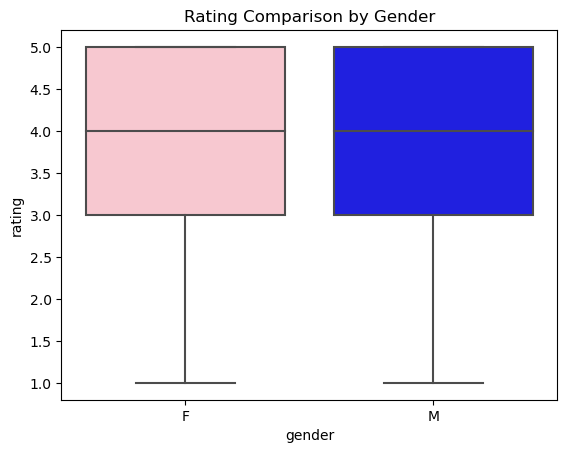

In [250]:
# 3. Plotting and Analysis
# Explore the correlation between gender/helpfulness/category and ratings

# 3.1 Gender vs Ratings
color=['pink', 'blue']
sns.boxplot(x='gender',y='rating', data=cleaned_data, palette=color)
plt.title('Rating Comparison by Gender')
plt.show()

### Description: Rating Comparison by Gender

- There are two boxes in the graph, a pink box represents rating reveiced from Female and an blue box represents rating reveiced from Male.

- There are ___no difference___ rating score recieved from __Male and Female__  
    - Both Female and Male have __the same rating score__ from scale 1 to 5.
    - Both Female and Male have __the same Median__, which is ___4.___ 
    - There is __no outliers__ both Female and Male.

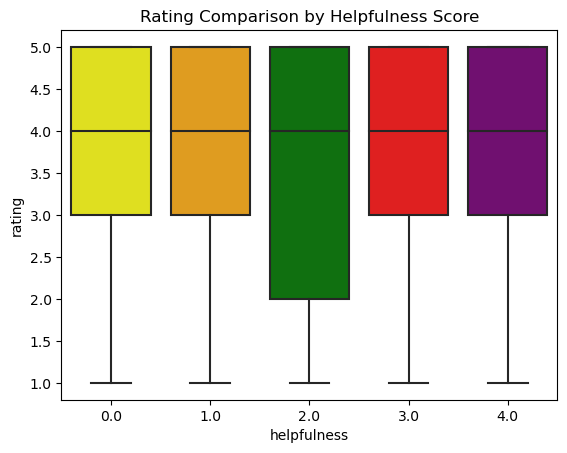

In [253]:
# 3.2 Gender vs Helpfulness
color=['yellow', 'orange','green','red','purple']
sns.boxplot(x='helpfulness',y='rating', data=cleaned_data, palette=color)
plt.title('Rating Comparison by Helpfulness Score')
plt.show()

### Description: Rating Comparison by Helpfulness Score

- There are ___5 boxes___ represents helpfulness scores of the ratings from 0 to 4.
- The rating which scored 2 has __the least helpfullness score.__
    - Customers think the ratings which are 2 are the most unhelpful for them)
- Other rating scores have __the similar helpfulness score.__
- Each helpfulness scores have __the same median.__ 
    - Median is 4

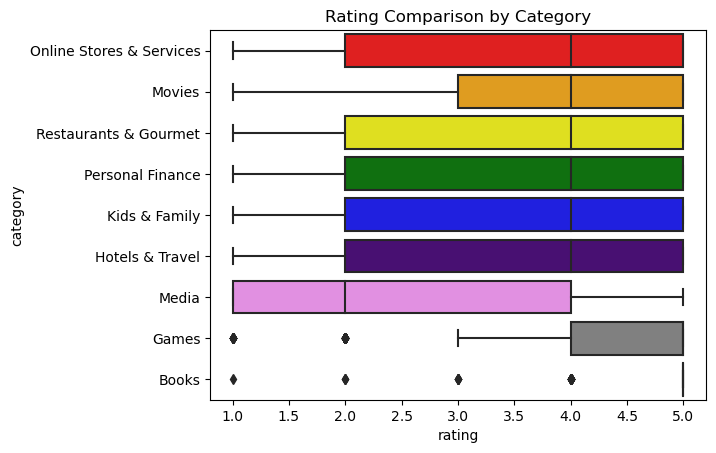

In [257]:
# 3.3 Gender vs category
color=['red', 'orange','yellow','green','blue', 'indigo', 'violet', 'grey']
sns.boxplot(x='rating',y='category', data=cleaned_data, palette=color)
plt.title('Rating Comparison by Category')
plt.show()

### Description: Rating Comparison by Category

- There are 9 boxes represents __9 product categories.__
    - __Media__ is the product categories that have ___the lowest rating score.___ and also __the lowest median__ which is ___2.___
    - __Games__ is the product categories that have ___the highest rating score.___
    - There are __6 product categories___ which are Online stores & Service, Movies, Restuarant & Gourmet, Personal Finance, Kids & Family, Hotels & Travel have __the same Median__, which is ___4.___
    - ___Games and Books___ are only 2 product categories which have some ___outliers.___

#### Q4. Detect and remove outliers

We may define outlier users, reviews and items with three rules (if a record meets one of the rules, it is regarded as an outlier):

1. reviews of which the helpfulness is no more than 2
2. users who rate less than 7 items
3. items that receives less than 11 ratings

Please remove the corresponding records in the csv file that involves outlier users, reviews and items. You need to follow the order of rules to perform data cleaning operations. After that, __print the length of the data__.

In [280]:
# 4.1 Reviews of which the helpfulness is no more than 2
review_outliers = cleaned_data[cleaned_data['helpfulness'] > 2]
data = cleaned_data[cleaned_data['helpfulness'].isin(reviews_outlier)]
print('The number of reviews without outlier is: ', len(review_outliers))

# 4.2 Users who rate less than 7 items
rating_counts = cleaned_data.groupby('userId')['rating'].size()
user_rating_not_outliers = rating_counts[rating_counts >= 7].index
data = cleaned_data[cleaned_data['userId'].isin(user_rating_not_outliers)]
print('The number of users who rate less then 7 times is: ', len(user_rating_not_outliers))

# 4.3 Items that receive less than 11 ratings
rating_counts_item = cleaned_data.groupby('item')['rating'].size()
item_outliers = rating_counts_item[rating_counts_item >= 11].index
data = cleaned_data[cleaned_data['item_id'].isin(item_outliers)]
print('The number of item which recieve less than 11 ratings is: ', len(item_outliers))

The number of reviews without outlier is:  13643
The number of users who rate less then 7 times is:  487
The number of item which recieve less than 11 ratings is:  89
